## Personal Notebook, Random Forest, Jani Laakso

##### Using the cleaned_100k.csv and the same skeleton as in the assignment notebook.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from imblearn.pipeline import Pipeline          # NOT sklearn's Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (classification_report,
                            ConfusionMatrixDisplay,
                            accuracy_score, f1_score)
import seaborn as sns


### Reading sampled csv and splitting data 60/20/20

In [2]:
df = pd.read_csv("cleaned_100k.csv", low_memory=False)

y = df["Attack Type"]
X = df.drop("Attack Type", axis=1)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25, random_state=42, stratify=y_train_val)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (60000, 52) Val: (20000, 52) Test: (20000, 52)


### Creating skeleton

In [3]:

# Agreed 10-feature list

FEATURES = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Length of Fwd Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Fwd Packet Length Mean",
    "Bwd Packet Length Mean",
    "Packet Length Mean",
    "Packet Length Std",
    "Average Packet Size",
]
missing = [f for f in FEATURES if f not in X_train.columns]
assert not missing, f"These features are not in the data: {missing}"

X_train_sel = X_train[FEATURES]
X_val_sel   = X_val[FEATURES]
X_test_sel  = X_test[FEATURES]

CV_FOLDS = 3
SCORING  = "f1_macro"
N_JOBS   = -1

def run_experiment(clf, param_grid, label, use_smote=True, use_pca=True, use_scaler=True, use_lda=False, use_poly=False):

    steps = []

    # 1. scaling
    if use_scaler:
        steps.append(("scaler", StandardScaler()))

    if use_poly:
        steps.append(("poly", PolynomialFeatures(degree=2))) # 29.4. added for polynomial features testing

    # 2. SMOTE (only training data)
    if use_smote:
        steps.append(("smote", SMOTE(random_state=42)))
    # 3.1 Use LDA 
    if use_lda:
        steps.append(("lda", LDA()))

    # 3.2 OR, use PCA (valinnainen)
    if use_pca:
        steps.append(("pca", PCA()))

    # 4. model
    steps.append(("clf", clf))

    pipe = Pipeline(steps)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        cv=CV_FOLDS,
        scoring=SCORING,
        n_jobs=N_JOBS,
        verbose=1
    )

    grid.fit(X_train_sel, y_train)

    y_val_pred = grid.predict(X_val_sel)
    y_test_pred = grid.predict(X_test_sel)

    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average="macro")

    test_acc = accuracy_score(y_test, y_test_pred)
    test_f1 = f1_score(y_test, y_test_pred, average="macro")

    # confusion matrix
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_test_pred, ax=ax, xticks_rotation=45, colorbar=False
    )
    ax.set_title(f"{label} — Test Confusion Matrix")
    plt.tight_layout()
    plt.show()

    print(f"\n=== {label} ===")
    print("Best params:", grid.best_params_)
    print(f"Validation acc: {val_acc:.4f}, f1: {val_f1:.4f}")
    print(f"Test acc: {test_acc:.4f}, f1: {test_f1:.4f}")
    print(classification_report(y_test, y_test_pred, digits=3))

    return {
        "label": label,
        "grid": grid,
        "best_params": grid.best_params_,
        "val_acc": val_acc,
        "val_f1_macro": val_f1,
        "test_acc": test_acc,
        "test_f1_macro": test_f1,
        "smote": use_smote,
        "pca": use_pca
    }

all_results = []


Fitting 3 folds for each of 12 candidates, totalling 36 fits


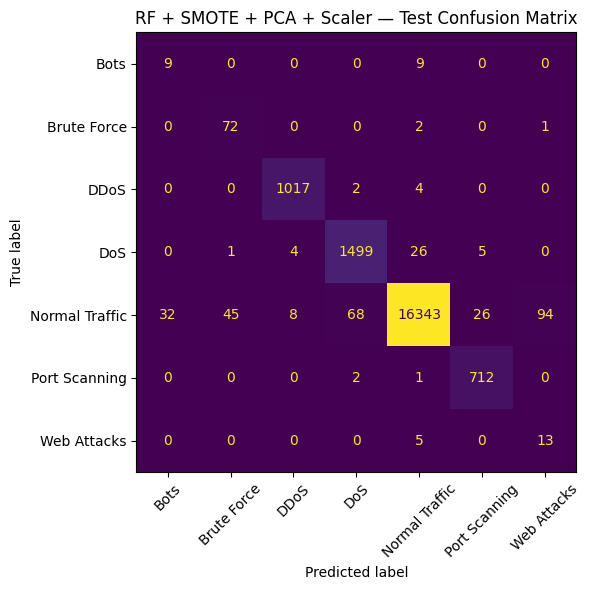


=== RF + SMOTE + PCA + Scaler ===
Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 50, 'pca__n_components': 8}
Validation acc: 0.9828, f1: 0.7530
Test acc: 0.9832, f1: 0.7401
                precision    recall  f1-score   support

          Bots      0.220     0.500     0.305        18
   Brute Force      0.610     0.960     0.746        75
          DDoS      0.988     0.994     0.991      1023
           DoS      0.954     0.977     0.965      1535
Normal Traffic      0.997     0.984     0.990     16616
 Port Scanning      0.958     0.996     0.977       715
   Web Attacks      0.120     0.722     0.206        18

      accuracy                          0.983     20000
     macro avg      0.693     0.876     0.740     20000
  weighted avg      0.989     0.983     0.986     20000

Fitting 3 folds for each of 12 candidates, totalling 36 fits


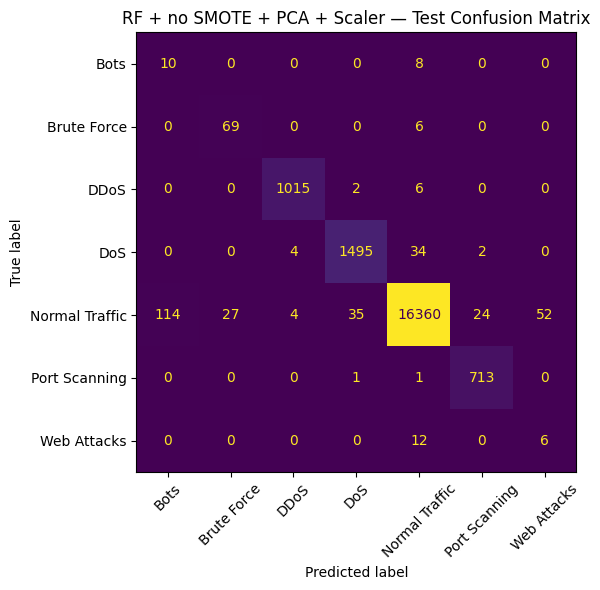


=== RF + no SMOTE + PCA + Scaler ===
Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 15, 'clf__min_samples_split': 5, 'clf__n_estimators': 100, 'pca__n_components': 8}
Validation acc: 0.9835, f1: 0.7095
Test acc: 0.9834, f1: 0.7205
                precision    recall  f1-score   support

          Bots      0.081     0.556     0.141        18
   Brute Force      0.719     0.920     0.807        75
          DDoS      0.992     0.992     0.992      1023
           DoS      0.975     0.974     0.975      1535
Normal Traffic      0.996     0.985     0.990     16616
 Port Scanning      0.965     0.997     0.981       715
   Web Attacks      0.103     0.333     0.158        18

      accuracy                          0.983     20000
     macro avg      0.690     0.822     0.720     20000
  weighted avg      0.990     0.983     0.987     20000

Fitting 3 folds for each of 12 candidates, totalling 36 fits


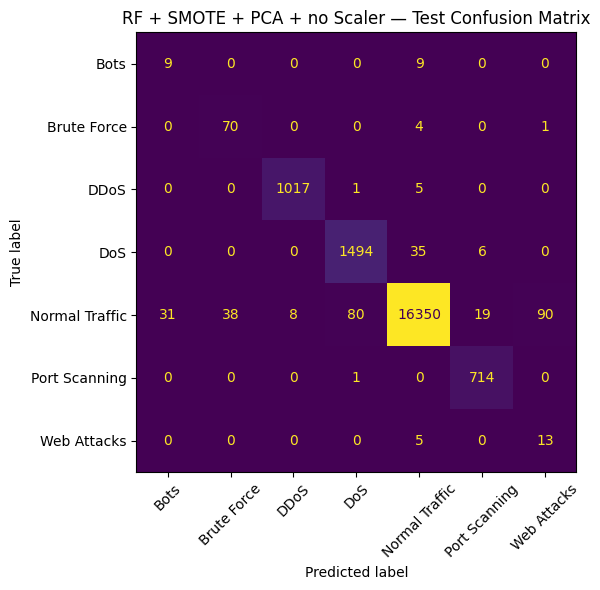


=== RF + SMOTE + PCA + no Scaler ===
Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100, 'pca__n_components': 8}
Validation acc: 0.9836, f1: 0.7556
Test acc: 0.9833, f1: 0.7449
                precision    recall  f1-score   support

          Bots      0.225     0.500     0.310        18
   Brute Force      0.648     0.933     0.765        75
          DDoS      0.992     0.994     0.993      1023
           DoS      0.948     0.973     0.960      1535
Normal Traffic      0.996     0.984     0.990     16616
 Port Scanning      0.966     0.999     0.982       715
   Web Attacks      0.125     0.722     0.213        18

      accuracy                          0.983     20000
     macro avg      0.700     0.872     0.745     20000
  weighted avg      0.989     0.983     0.986     20000

Fitting 3 folds for each of 12 candidates, totalling 36 fits


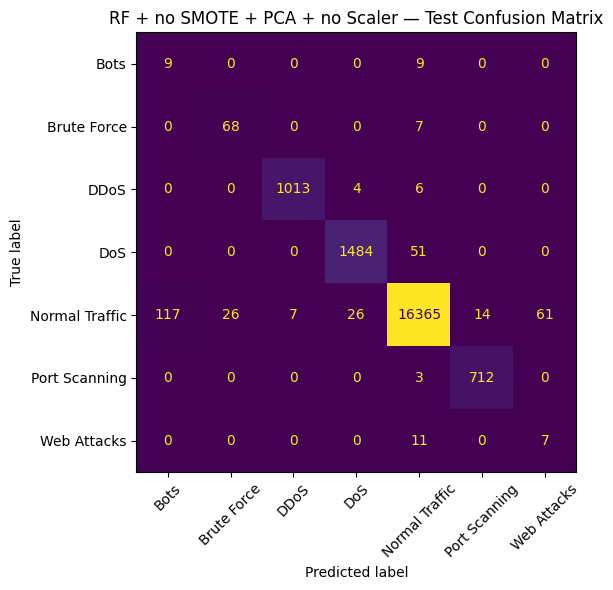


=== RF + no SMOTE + PCA + no Scaler ===
Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 15, 'clf__min_samples_split': 5, 'clf__n_estimators': 100, 'pca__n_components': 8}
Validation acc: 0.9821, f1: 0.7072
Test acc: 0.9829, f1: 0.7194
                precision    recall  f1-score   support

          Bots      0.071     0.500     0.125        18
   Brute Force      0.723     0.907     0.805        75
          DDoS      0.993     0.990     0.992      1023
           DoS      0.980     0.967     0.973      1535
Normal Traffic      0.995     0.985     0.990     16616
 Port Scanning      0.981     0.996     0.988       715
   Web Attacks      0.103     0.389     0.163        18

      accuracy                          0.983     20000
     macro avg      0.692     0.819     0.719     20000
  weighted avg      0.990     0.983     0.986     20000

Fitting 3 folds for each of 4 candidates, totalling 12 fits


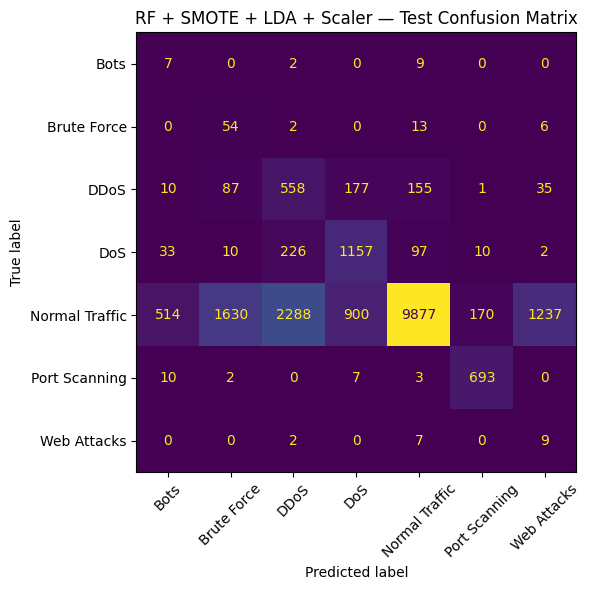


=== RF + SMOTE + LDA + Scaler ===
Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100, 'lda__n_components': 1}
Validation acc: 0.6207, f1: 0.3758
Test acc: 0.6178, f1: 0.3701
                precision    recall  f1-score   support

          Bots      0.012     0.389     0.024        18
   Brute Force      0.030     0.720     0.058        75
          DDoS      0.181     0.545     0.272      1023
           DoS      0.516     0.754     0.613      1535
Normal Traffic      0.972     0.594     0.738     16616
 Port Scanning      0.793     0.969     0.872       715
   Web Attacks      0.007     0.500     0.014        18

      accuracy                          0.618     20000
     macro avg      0.359     0.639     0.370     20000
  weighted avg      0.885     0.618     0.705     20000

Fitting 3 folds for each of 4 candidates, totalling 12 fits


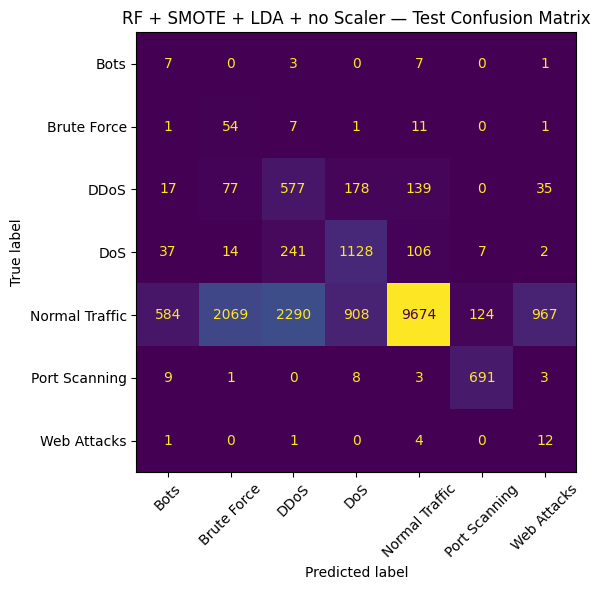


=== RF + SMOTE + LDA + no Scaler ===
Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100, 'lda__n_components': 1}
Validation acc: 0.6063, f1: 0.3691
Test acc: 0.6071, f1: 0.3711
                precision    recall  f1-score   support

          Bots      0.011     0.389     0.021        18
   Brute Force      0.024     0.720     0.047        75
          DDoS      0.185     0.564     0.279      1023
           DoS      0.507     0.735     0.600      1535
Normal Traffic      0.973     0.582     0.728     16616
 Port Scanning      0.841     0.966     0.899       715
   Web Attacks      0.012     0.667     0.023        18

      accuracy                          0.607     20000
     macro avg      0.365     0.660     0.371     20000
  weighted avg      0.887     0.607     0.698     20000

Fitting 3 folds for each of 4 candidates, totalling 12 fits


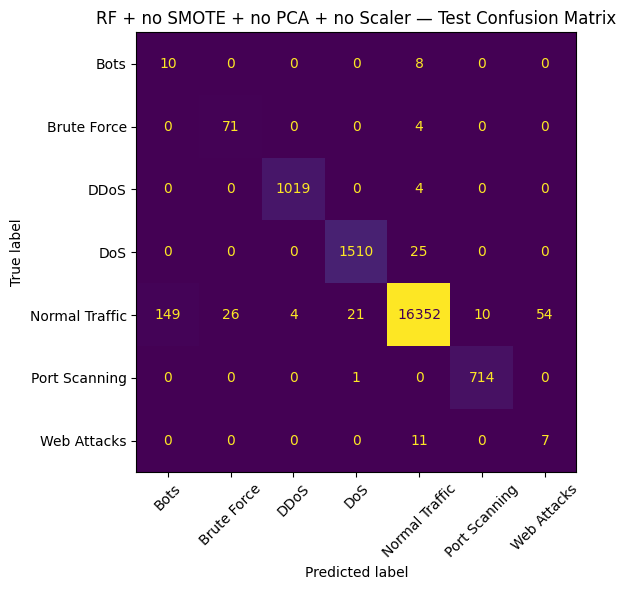


=== RF + no SMOTE + no PCA + no Scaler ===
Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': 15, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Validation acc: 0.9839, f1: 0.7093
Test acc: 0.9841, f1: 0.7256
                precision    recall  f1-score   support

          Bots      0.063     0.556     0.113        18
   Brute Force      0.732     0.947     0.826        75
          DDoS      0.996     0.996     0.996      1023
           DoS      0.986     0.984     0.985      1535
Normal Traffic      0.997     0.984     0.990     16616
 Port Scanning      0.986     0.999     0.992       715
   Web Attacks      0.115     0.389     0.177        18

      accuracy                          0.984     20000
     macro avg      0.696     0.836     0.726     20000
  weighted avg      0.993     0.984     0.988     20000

Fitting 3 folds for each of 4 candidates, totalling 12 fits


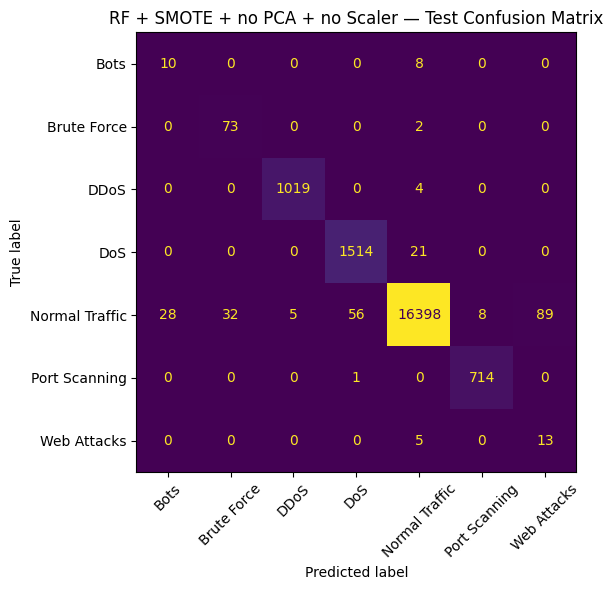


=== RF + SMOTE + no PCA + no Scaler ===
Best params: {'clf__class_weight': 'balanced', 'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 50}
Validation acc: 0.9867, f1: 0.7699
Test acc: 0.9870, f1: 0.7630
                precision    recall  f1-score   support

          Bots      0.263     0.556     0.357        18
   Brute Force      0.695     0.973     0.811        75
          DDoS      0.995     0.996     0.996      1023
           DoS      0.964     0.986     0.975      1535
Normal Traffic      0.998     0.987     0.992     16616
 Port Scanning      0.989     0.999     0.994       715
   Web Attacks      0.127     0.722     0.217        18

      accuracy                          0.987     20000
     macro avg      0.719     0.888     0.763     20000
  weighted avg      0.992     0.987     0.989     20000


ALL EXPERIMENTS COMPLETED

 BEST MODEL:
label            RF + SMOTE + no PCA + no Scaler
test_f1_macro                           0.763049
test_acc    

In [ ]:
# All 8 variations
from sklearn.ensemble import RandomForestClassifier

# Define parameter grids
rf_param_grid = {
    "pca__n_components": [4, 6, 8],
    "clf__n_estimators": [50, 100],
    "clf__max_depth": [None, 15],
    "clf__min_samples_split": [5],
    "clf__class_weight": ["balanced"],
}

rf_param_grid_lda = {
    "lda__n_components": [1],  
    "clf__n_estimators": [50, 100],
    "clf__max_depth": [None, 15],
    "clf__min_samples_split": [5],
    "clf__class_weight": ["balanced"],
}

rf_param_grid_no_pca = {
    "clf__n_estimators": [50, 100],
    "clf__max_depth": [None, 15],
    "clf__min_samples_split": [5],
    "clf__class_weight": ["balanced"],
}

# 1. RF with SMOTE + PCA + Scaler
all_results.append(run_experiment(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    "RF + SMOTE + PCA + Scaler"
))

# 2. RF with no SMOTE + PCA + Scaler
all_results.append(run_experiment(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    "RF + no SMOTE + PCA + Scaler",
    use_smote=False
))

# 3. RF with SMOTE + PCA + no Scaler
all_results.append(run_experiment(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    "RF + SMOTE + PCA + no Scaler",
    use_scaler=False
))

# 4. RF with no SMOTE + PCA + no Scaler
all_results.append(run_experiment(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    "RF + no SMOTE + PCA + no Scaler",
    use_smote=False,
    use_scaler=False
))

# 5. RF with SMOTE + LDA + Scaler
all_results.append(run_experiment(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid_lda,
    "RF + SMOTE + LDA + Scaler",
    use_lda=True,
    use_pca=False  # Disable PCA when using LDA
))

# 6. RF with SMOTE + LDA + no Scaler
all_results.append(run_experiment(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid_lda,
    "RF + SMOTE + LDA + no Scaler",
    use_lda=True,
    use_pca=False,  # Disable PCA when using LDA
    use_scaler=False
))

# 7. RF with no SMOTE + no PCA + no Scaler
all_results.append(run_experiment(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid_no_pca,
    "RF + no SMOTE + no PCA + no Scaler",
    use_smote=False,
    use_pca=False,
    use_scaler=False
))

# 8. RF with SMOTE + no PCA + no Scaler
all_results.append(run_experiment(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid_no_pca,
    "RF + SMOTE + no PCA + no Scaler",
    use_pca=False,
    use_scaler=False
))

# Print summary
print("\n" + "="*80)
print("ALL EXPERIMENTS COMPLETED")
print("="*80)

results_df = pd.DataFrame(all_results)
results_df_sorted = results_df.sort_values('test_f1_macro', ascending=False)

print("\n BEST MODEL:")
print(results_df_sorted.iloc[0][['label', 'test_f1_macro', 'test_acc']])

print("\n ALL RESULTS (sorted by F1 score):")
for idx, row in results_df_sorted.iterrows():
    print(f"{row['label']}: F1={row['test_f1_macro']:.4f}, Acc={row['test_acc']:.4f}")